# Bayesian hierarchical field-trial model

This notebook executes the v0.3.0 Bayesian extension of the public hop downy-mildew fungicide case.
It demonstrates partial pooling, posterior predictive checks, multi-chain diagnostics and genuine
leave-one-year-out posterior prediction.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from crop_protection_ps.bayesian_demo import run_bayesian_demo
from crop_protection_ps.hop_trial import (
    load_hop_trial,
    prepare_primary_analysis,
    prepare_timing_analysis,
)

ROOT

PosixPath('/mnt/data/crop-protection-predictive-science')

## Analysis population

The source-defined flooded 2019 trial remains in the raw file but is excluded from the primary
analysis before the Bayesian model is fitted.

In [2]:
raw = load_hop_trial(ROOT / "data" / "raw" / "richardson_gent_hop_downy_mildew.csv")
primary = prepare_primary_analysis(raw)
timing = prepare_timing_analysis(primary)
{
    "raw_rows": len(raw),
    "primary_rows": len(primary),
    "bayesian_timing_rows": len(timing),
    "model_years": sorted(timing["year"].unique().tolist()),
}

{'raw_rows': 290,
 'primary_rows': 227,
 'bayesian_timing_rows': 187,
 'model_years': [2017, 2018, 2020, 2021]}

## Execute the Bayesian release pipeline

The sampler uses four chains for the primary fit. Leave-one-year-out folds are refitted separately,
and predictions for the held-out year integrate over newly sampled year and nested-block effects.

In [3]:
summary = run_bayesian_demo(ROOT)
summary

{'model': {'response': 'sqrt_audpc standardised before fitting',
  'structure': 'population timing + partially pooled product effects + partially pooled product timing deviations + year random effects + year:block random effects',
  'chains': 4,
  'draws_per_chain': 800,
  'burn_in': 800,
  'thin': 2,
  'max_classical_rhat': 1.0011303090972277,
  'prior': {'variance_shape': 2.0,
   'residual_scale': 0.2,
   'product_scale': 0.1,
   'product_timing_scale': 0.05,
   'year_scale': 1.0,
   'year_block_scale': 0.1,
   'intercept_sd': 2.0,
   'population_timing_sd': 1.0}},
 'population_timing_effect': {'posterior_mean_delta_sqrt_audpc': 1.3306501118134044,
  'q05': 0.7236231547859738,
  'q95': 1.9420764606980698,
  'prob_late_greater_disease': 0.9996875},
 'posterior_predictive_checks': {'training_coverage_90': 0.93048128342246,
  'training_coverage_95': 0.9786096256684492,
  'negative_sqrt_prediction_fraction': 4.45632798573975e-05},
 'leave_one_year_out': {'rmse': 8.362473715071342,
  'mae

## Partially pooled timing effects

In [4]:
timing_effects = pd.read_csv(
    ROOT / "results" / "real_hop_trial" / "bayesian" / "posterior_timing_effects.csv"
)
timing_effects

,scope,treatment,posterior_mean_delta_sqrt_audpc,posterior_sd,q05,q50,q95,prob_late_greater_disease,rhat
0,population_average,ALL,1.330650,0.368327,0.723623,1.326877,1.942076,0.999687,0.999594
1,product,Curzate,1.411631,0.630478,0.391055,1.394882,2.481278,0.986875,0.999572
2,product,FungiPhi,1.315930,0.632131,0.270111,1.317618,2.353378,0.980000,0.999709
3,product,Presidio,1.737739,0.683913,0.636141,1.728447,2.878351,0.996875,1.000438
4,product,Ranman,1.343266,0.629641,0.288707,1.353469,2.346281,0.980000,0.999898
5,product,Revus,0.844685,0.643299,-0.221467,0.856716,1.890767,0.900000,1.000300


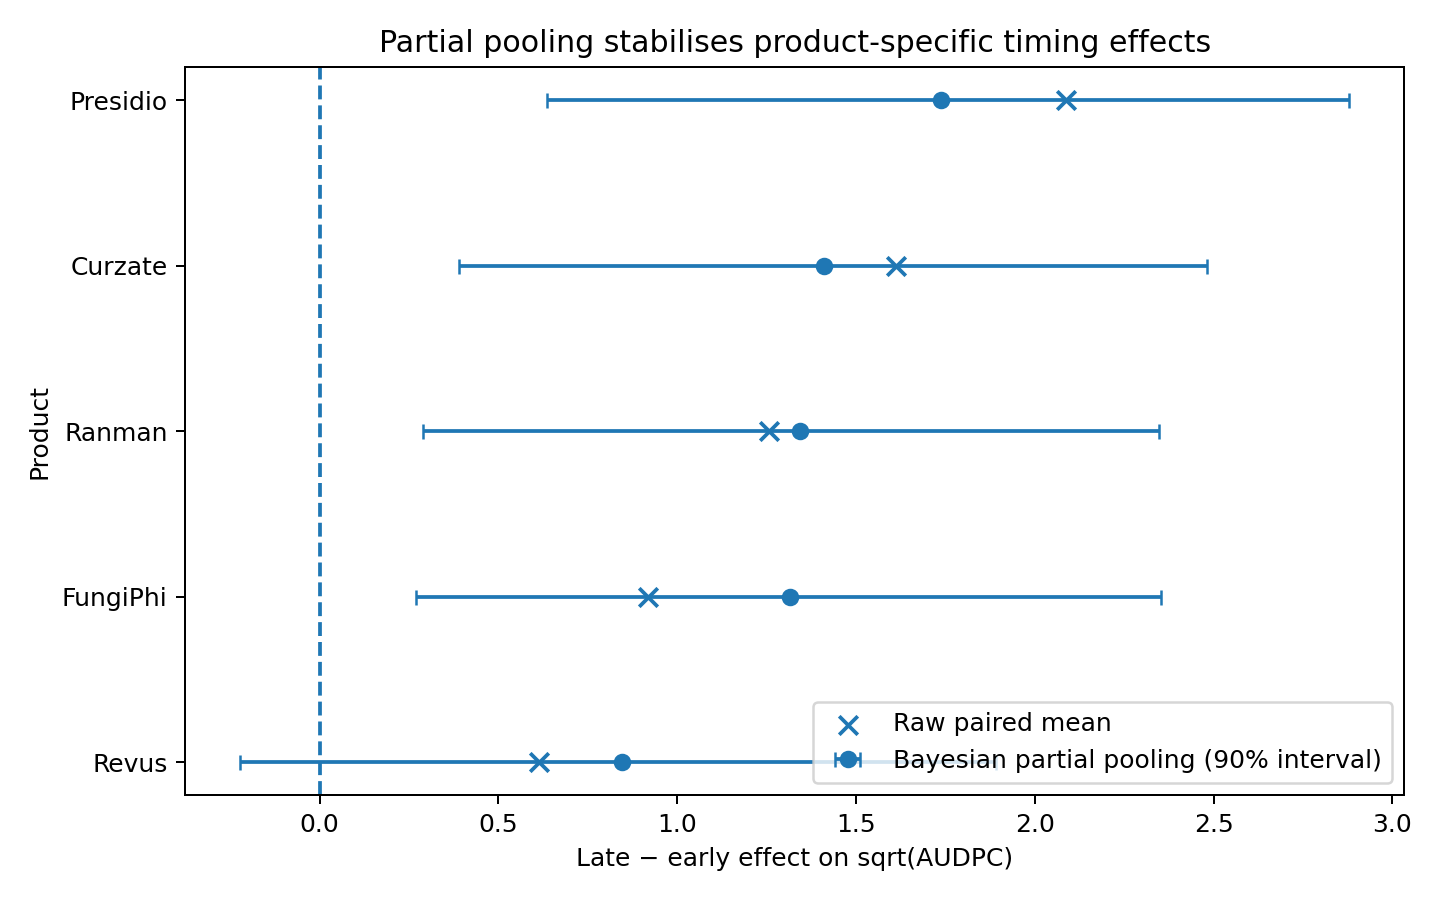

In [5]:
display(Image(filename=str(
    ROOT / "results" / "real_hop_trial" / "bayesian" / "figures" / "partial_pooling_timing_effects.png"
)))

## Posterior predictive checks

In [6]:
pd.read_csv(
    ROOT / "results" / "real_hop_trial" / "bayesian" / "posterior_predictive_checks.csv"
)

,statistic,observed,replicated_mean,replicated_q05,replicated_q95,bayesian_p_upper
0,mean,17.735069,17.734051,17.302565,18.170982,0.504167
1,sd,6.643555,6.673674,6.280233,7.062319,0.554167
2,minimum,4.108528,4.002468,1.599139,6.002535,0.506667
3,maximum,30.435670,31.867051,29.962891,34.251578,0.877500
4,row_coverage_90,0.930481,0.900000,NaN,NaN,NaN
5,row_coverage_95,0.978610,0.950000,NaN,NaN,NaN
6,negative_sqrt_prediction_fraction,0.000000,0.000045,NaN,NaN,NaN


## Genuine unseen-year prediction

The important diagnostic is not the in-sample fit. Each year is held out completely, the model is
refitted, and a new environmental random effect is integrated into the predictive distribution.

In [7]:
loyo = pd.read_csv(
    ROOT / "results" / "real_hop_trial" / "bayesian" / "leave_one_year_out_metrics.csv"
)
loyo

,held_out_year,n_test,rmse,mae,coverage_90,coverage_95,mean_pi90_width,mean_pi95_width,predictive_negative_fraction
0,2017,37,5.121654,4.533693,1.000000,1.000000,27.323007,34.016600,0.024257
1,2018,50,9.822333,9.396894,0.780000,0.960000,22.990437,28.144295,0.003550
2,2020,50,11.139211,10.923220,0.360000,0.720000,20.829608,25.319876,0.016375
3,2021,50,4.644392,3.923474,1.000000,1.000000,27.976391,34.777745,0.030550
4,ALL,187,8.362474,7.379284,0.770053,0.914439,24.603065,30.324652,NaN


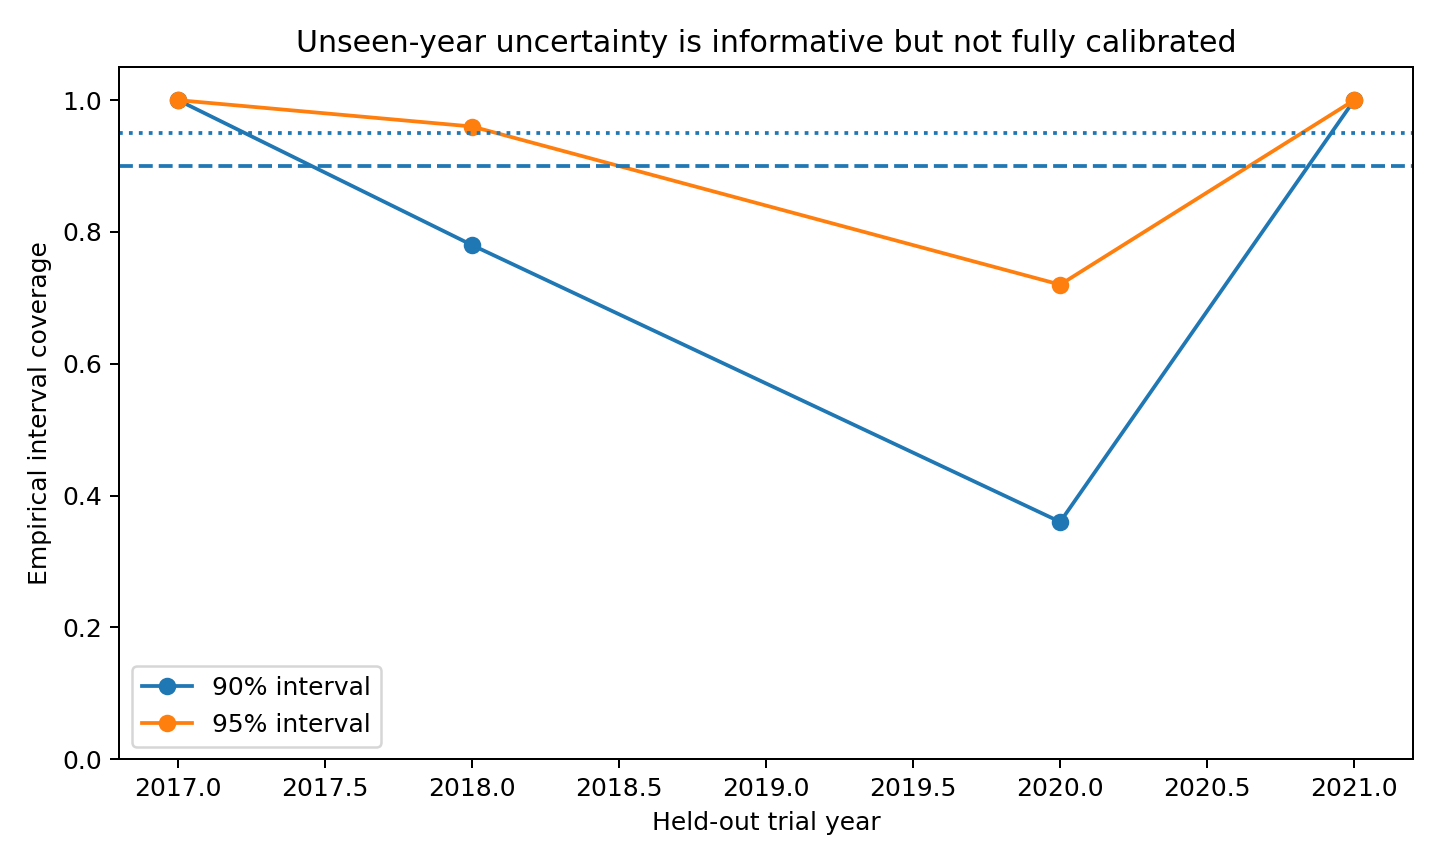

In [8]:
display(Image(filename=str(
    ROOT / "results" / "real_hop_trial" / "bayesian" / "figures" / "leave_one_year_out_coverage.png"
)))

## Prior sensitivity

In [9]:
pd.read_csv(
    ROOT / "results" / "real_hop_trial" / "bayesian" / "prior_sensitivity.csv"
)

,variance_prior_scale_multiplier,population_timing_mean,population_timing_q05,population_timing_q95,prob_late_greater_disease,year_sd_mean,residual_sd_mean
0,0.5,1.328288,0.744877,1.908152,0.999,5.710532,2.437214
1,1.0,1.360951,0.791847,1.979797,1.000,6.345808,2.453392
2,2.0,1.339708,0.759987,1.898180,0.999,7.488001,2.468951


## Interpretation

The main timing inference is stable under the tested variance-prior scales, while posterior
prediction into an unseen season remains imperfectly calibrated. The correct R&D implication is
that hierarchical pooling cannot substitute for missing environmental and biological state.
Future models should incorporate consistently measured weather, phenology, disease pressure and
application conditions, and should test product-by-environment interactions explicitly.